# cd_me — Pass 2.5 info / stats board

**Purpose:** see what PIM / VLOOP / TCOST / DCM̂ carry, how they relate, and honest desk uses.  
**Panel:** certified `panel_core_2venue` **n=9** (HL↔Deribit real quotes); spot_l2 subpanel **n=4**; `trade_synth` **QUARANTINED**.  
**Artifacts:** `out/info_features/` · `out/feature_stats/` · completeness [`../out/panel_completeness/`](../out/panel_completeness/) · use map [`../APPLICATIONS.md`](../APPLICATIONS.md)  
**Gate:** **0 Promote** — Hold monitors / research tiles only. Never soft-Promote TOB-cross α. Prior 10/10 synth-as-3-venue **retracted**.


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / "research" / "books" / "cd_me"
OUT = BOOK / "out"
SCRIPTS = BOOK / "scripts"
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(BOOK.parents[2]))
from _nb_common import load_json, SIGNAL_BOARD
from certified_panel import load_certified, primary_days, spot_l2_days

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def show_pngs(fig_dir: Path, pattern="*.png"):
    if not fig_dir.is_dir():
        print("missing", fig_dir)
        return
    for p in sorted(fig_dir.glob(pattern)):
        display(Markdown(f"**{p.name}** — `{p.relative_to(BOOK)}`"))
        display(Image(filename=str(p)))

info = load_json(OUT / "info_features" / "info_features.json") or {}
stats = load_json(OUT / "feature_stats" / "feature_stats.json") or {}
cands = load_json(OUT / "info_features" / "candidates.json") or info.get("candidates") or {}
cert = load_certified()
PRIMARY = primary_days(cert)
SPOT = spot_l2_days(cert)
print("BOOK", BOOK)
print("certified primary n=", len(PRIMARY), PRIMARY)
print("spot_l2 subpanel n=", len(SPOT), SPOT)
print("info ok", bool(info), "stats ok", bool(stats))
print("n_days", (info.get("meta") or {}).get("n_days"), (info.get("meta") or {}).get("days"))
print("trade_synth QUARANTINED — never primary")


BOOK /home/dev/srv/ares-microstructure/research/books/cd_me
certified primary n= 9 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
spot_l2 subpanel n= 4 ['2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
info ok True stats ok True
n_days 9 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
trade_synth QUARANTINED — never primary


## Candidate board (`info.*`)

Decisions from the Pass-2.5 dig. Promote count must stay **0**.


In [2]:
print(f"{'id':36s} {'gate':6s} evidence / use")
print("-" * 100)
for k, v in (cands or {}).items():
    if str(k).startswith("_"):
        continue
    ev = (v.get("evidence") or v.get("use") or "")[:70]
    print(f"{k:36s} {str(v.get('decision')):6s} {ev}")
roll = cands.get("_rollup") or {}
print("\nrollup:", roll)

print("\nfull SIGNAL_BOARD:")
print(f"{'id':34s} {'gate':6s} note")
print("-" * 88)
for i, g, n in SIGNAL_BOARD:
    print(f"{i:34s} {g:6s} {n}")


id                                   gate   evidence / use
----------------------------------------------------------------------------------------------------
info.object_leadlag_map              Hold   lead-lag dig vs mid_ret/RV/notional/funding/basis on hourly panel; PIM
info.pim_dcm_incremental             Hold   partial corr(PIM,DCM|RV)≈0.38441704959837886; ΔR²(DCM|RV)≈0.1493744604
info.elasticity_after_rv             Hold   partial corr(PIM,VLM|RV)≈-0.4596431148630297; ΔR²≈0.20423871701565177;
info.vloop_tcost_stress_split        Hold   corr(VLOOP,TCOST) calm≈0.24166783829588623 vs stress≈0.171994790323769
info.kraken_spot_vs_synth            Hold   spot_l2 days=0 synth=0; Δday_mean_PIM(spot−synth)≈None; synth legs rem
info.day_factor_commonality          Hold   PIM ToD PCA PC1 explained≈0.42122710216982784; day-feature PCA PC1≈0.9
info.object_use_map                  Hold   APPLICATIONS.md use map — risk/exec/policy; 0 Promote
alpha.tob_cross_arb                  Kill   info dig

## Key statistical findings

Numbers from `info_features.json` + `feature_stats.json` (day-block bootstrap where noted).


In [3]:
inc = info.get("incremental") or {}
dep = info.get("dependence") or {}
stress = info.get("vloop_tcost_stress") or {}
kr = info.get("kraken_sensitivity") or {}
factor = info.get("factor") or {}
bayes = info.get("bayes_corr") or {}
ll = (info.get("lead_lag") or {}).get("pim->|mid_ret") or {}

rows = [
    ("corr(VLOOP,TCOST) pooled", dep.get("vloop__tcost", {}).get("pearson"),
     (dep.get("vloop__tcost") or {}).get("day_block")),
    ("corr(PIM,VLM) pooled", dep.get("pim__notional", {}).get("pearson"),
     (dep.get("pim__notional") or {}).get("day_block")),
    ("corr(PIM,DCM) raw", inc.get("raw_corr_pim_dcm", {}).get("pearson"),
     inc.get("day_block_pim_dcm")),
    ("partial(PIM,DCM|RV)", inc.get("partial_pim_dcm_ctrl_rv", {}).get("partial_r"), None),
    ("ΔR² DCM after RV", inc.get("delta_r2_dcm_after_rv"), None),
    ("partial(PIM,VLM|RV)", inc.get("partial_pim_vlm_ctrl_rv", {}).get("partial_r"), None),
    ("ΔR² VLM after RV", inc.get("delta_r2_vlm_after_rv"), None),
    ("VLOOP↔TCOST calm", (stress.get("corr_calm") or {}).get("pearson"), None),
    ("VLOOP↔TCOST stress", (stress.get("corr_stress") or {}).get("pearson"), None),
    ("day-feature PCA PC1", (factor.get("day_feature_pca") or {}).get("pc1_explained"), None),
    ("PIM ToD PCA PC1", (factor.get("pim_tod_pca") or {}).get("pc1_explained"), None),
    ("PIM↔mid_ret best lag/corr", f"lag={ll.get('pooled',{}).get('best_lag')} r={ll.get('pooled',{}).get('best_corr')}", None),
]
print(f"{'claim':28s} {'point':>12s}  day-block CI")
print("-" * 72)
for name, pt, block in rows:
    ci = ""
    if isinstance(block, dict) and block.get("ci_lo") is not None:
        ci = f"[{block.get('ci_lo'):.3f}, {block.get('ci_hi'):.3f}]"
    if isinstance(pt, float):
        print(f"{name:28s} {pt:12.4f}  {ci}")
    else:
        print(f"{name:28s} {str(pt):>12s}  {ci}")

print("\nKraken modes:")
for mode, blob in (kr.get("modes") or {}).items():
    print(f"  {mode}: n_days={blob.get('n_days')} PIM↔DCM r={ (blob.get('corr_pim_dcm') or {}).get('pearson') } "
          f"VLOOP↔TCOST r={ (blob.get('corr_vloop_tcost') or {}).get('pearson') }")
print("  Δ day_mean_PIM(spot−synth) =", kr.get("delta_day_mean_pim_spot_minus_synth"))

print("\nFisher-z Bayes (descriptive, not α):")
for k, b in bayes.items():
    print(f"  {k}: mean_r={b.get('mean_r')} CrI={b.get('cri95')}")


claim                               point  day-block CI
------------------------------------------------------------------------
corr(VLOOP,TCOST) pooled           0.6236  [0.480, 0.707]
corr(PIM,VLM) pooled              -0.4613  [-0.545, -0.354]
corr(PIM,DCM) raw                  0.2484  [-0.157, 0.454]
partial(PIM,DCM|RV)                0.3844  
ΔR² DCM after RV                   0.1494  
partial(PIM,VLM|RV)               -0.4596  
ΔR² VLM after RV                   0.2042  
VLOOP↔TCOST calm                   0.2417  
VLOOP↔TCOST stress                 0.1720  
day-feature PCA PC1                0.9950  
PIM ToD PCA PC1                    0.4212  
PIM↔mid_ret best lag/corr    lag=2 r=-0.12609956913052647  

Kraken modes:
  absent_2venue: n_days=9 PIM↔DCM r=0.2484179623497117 VLOOP↔TCOST r=0.6235819063339713
  Δ day_mean_PIM(spot−synth) = None

Fisher-z Bayes (descriptive, not α):
  pim_dcm: mean_r=0.2484179623497117 CrI=[-0.008189818885376865, 0.47432952547614987]
  vloop_tcost: mean

## Info dig figures

Lead-lag, incremental partials, ToD, Kraken sensitivity, stress split, day factor, use map.


**fig_day_factor_pc1.png** — `out/info_features/figs/fig_day_factor_pc1.png`

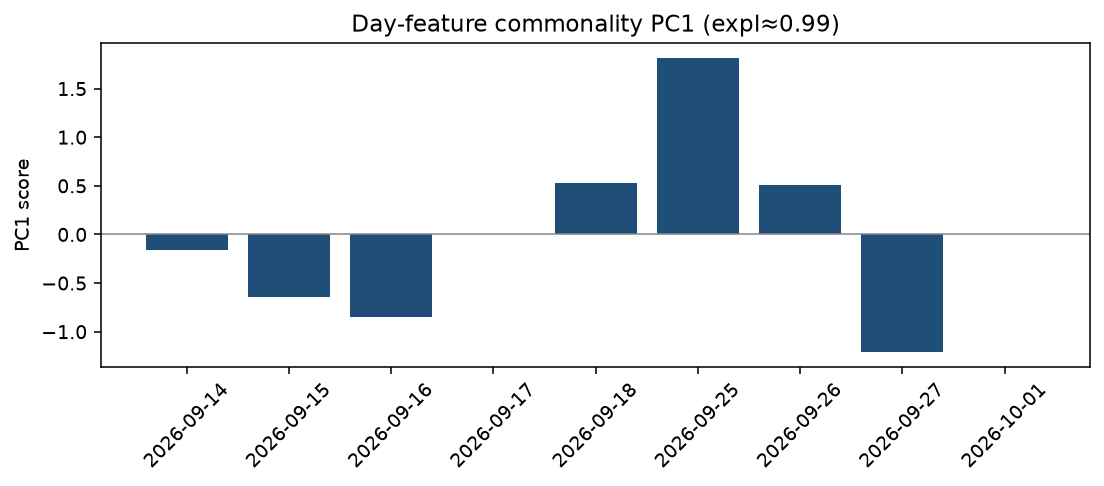

**fig_incremental_partial.png** — `out/info_features/figs/fig_incremental_partial.png`

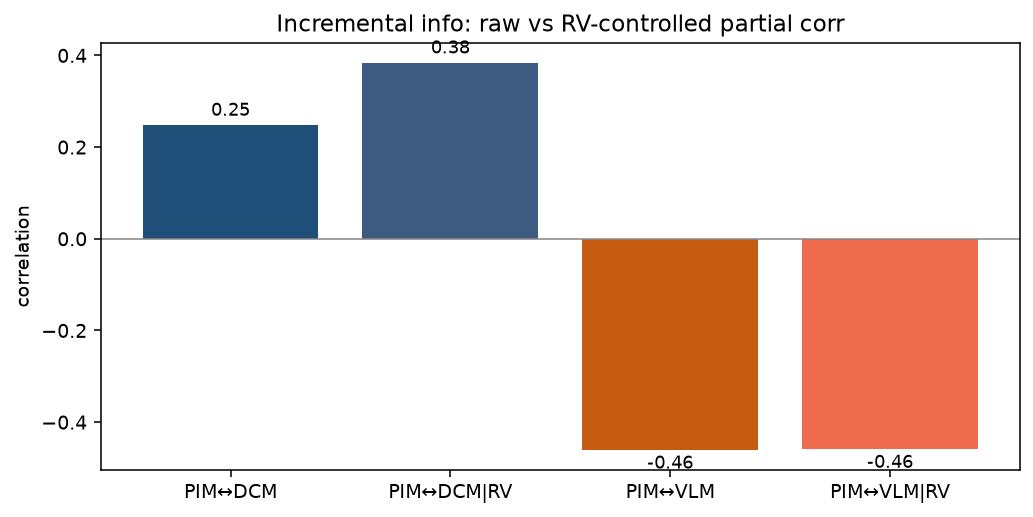

**fig_kraken_mode_sensitivity.png** — `out/info_features/figs/fig_kraken_mode_sensitivity.png`

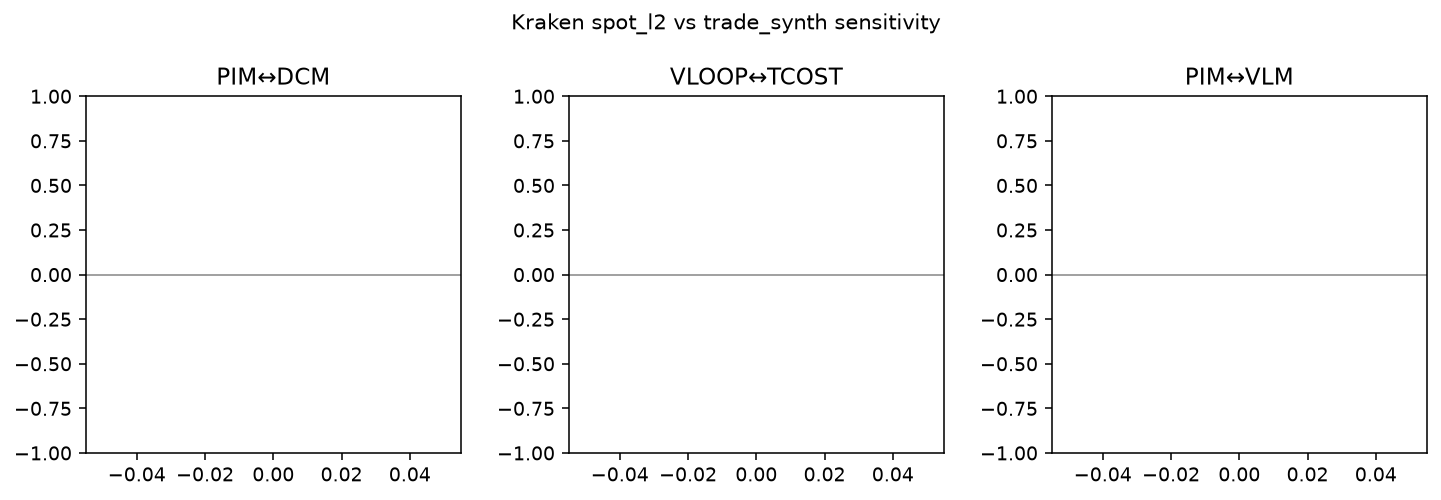

**fig_leadlag_midret.png** — `out/info_features/figs/fig_leadlag_midret.png`

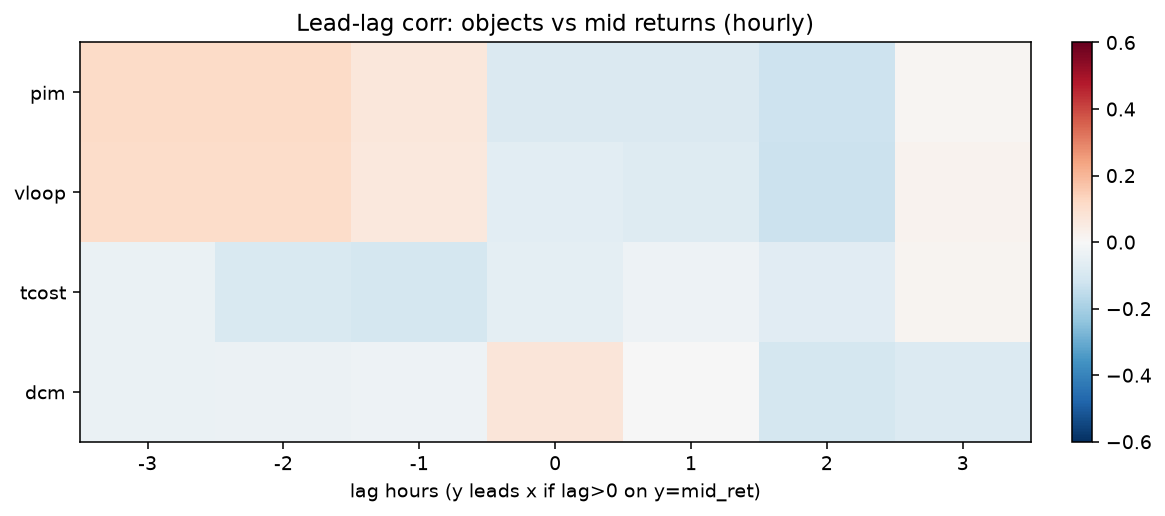

**fig_tod_pim_dcm.png** — `out/info_features/figs/fig_tod_pim_dcm.png`

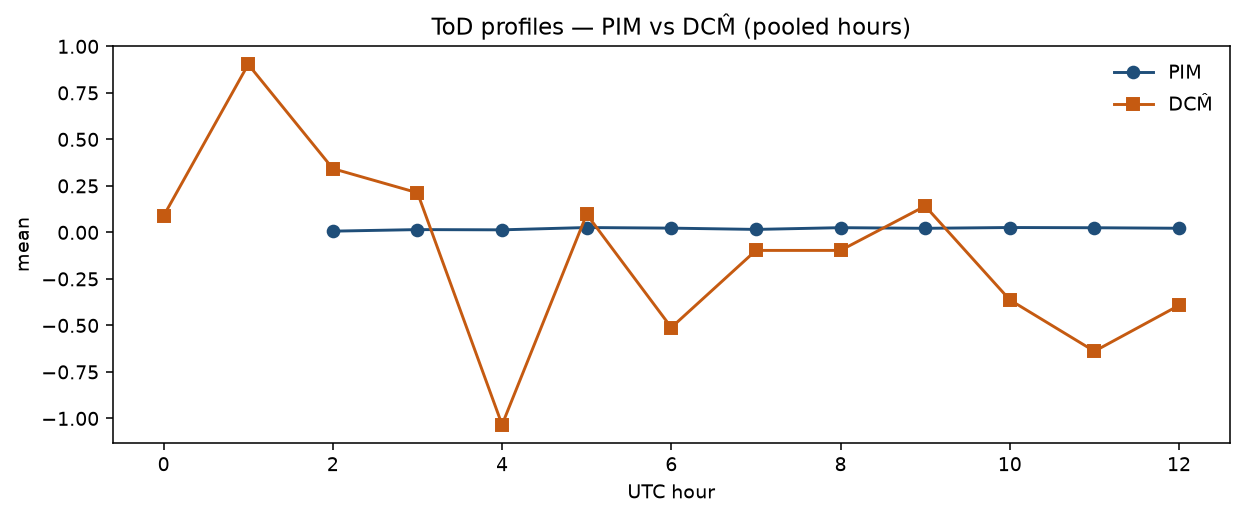

**fig_use_map.png** — `out/info_features/figs/fig_use_map.png`

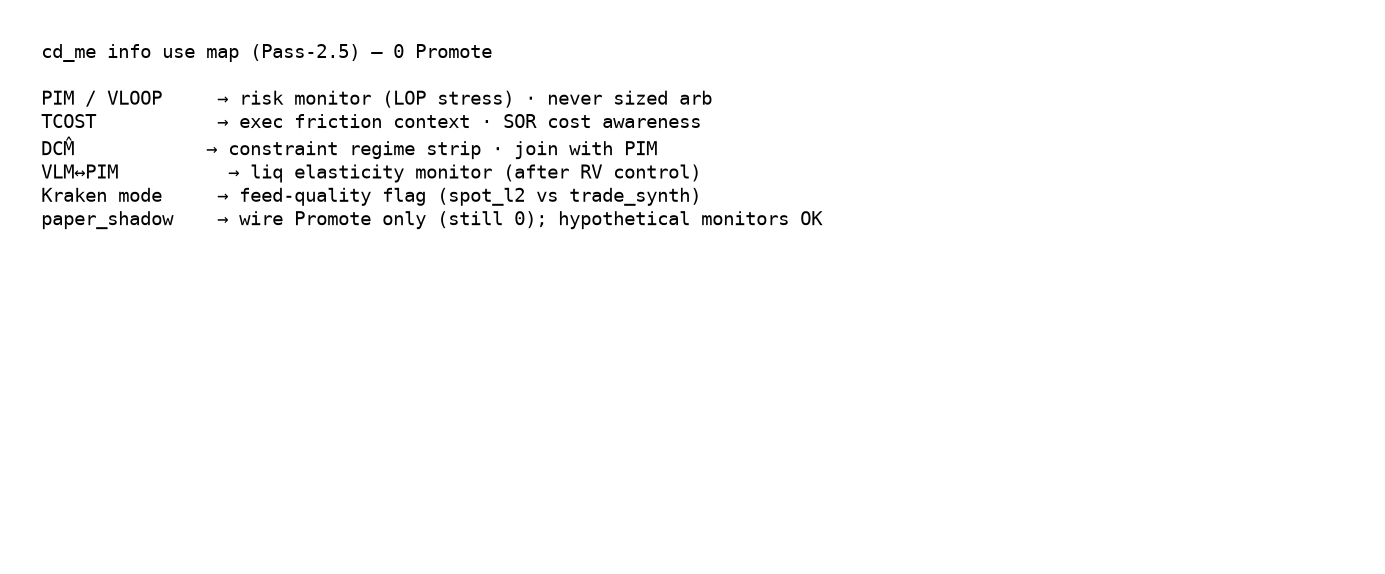

**fig_vloop_tcost_stress.png** — `out/info_features/figs/fig_vloop_tcost_stress.png`

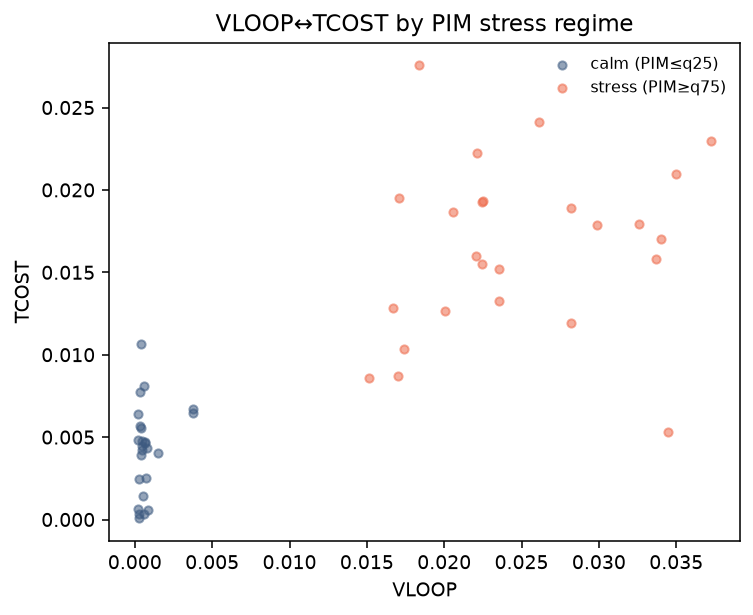

In [4]:
show_pngs(OUT / "info_features" / "figs")


## Feature stats figures

Univariate · corr forest (day-block CI) · ToD heatmap · chrono split · light Bayes CrI · IRF lead-lag.


**fig_bayes_corr_cri.png** — `out/feature_stats/figs/fig_bayes_corr_cri.png`

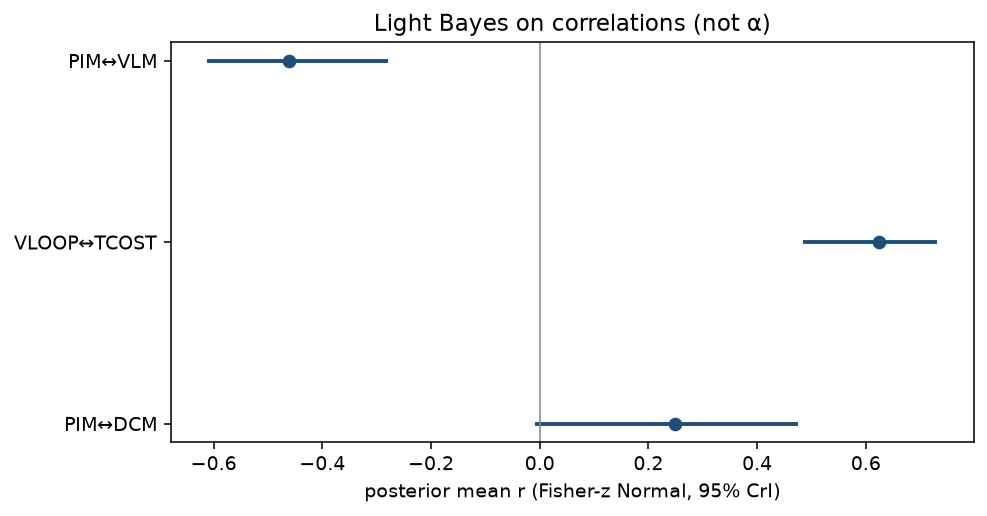

**fig_chrono_split.png** — `out/feature_stats/figs/fig_chrono_split.png`

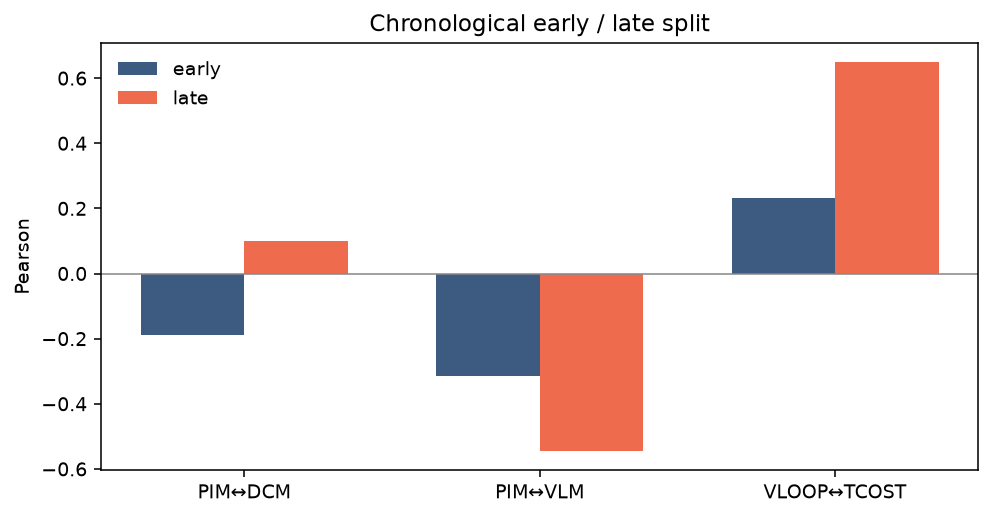

**fig_corr_forest.png** — `out/feature_stats/figs/fig_corr_forest.png`

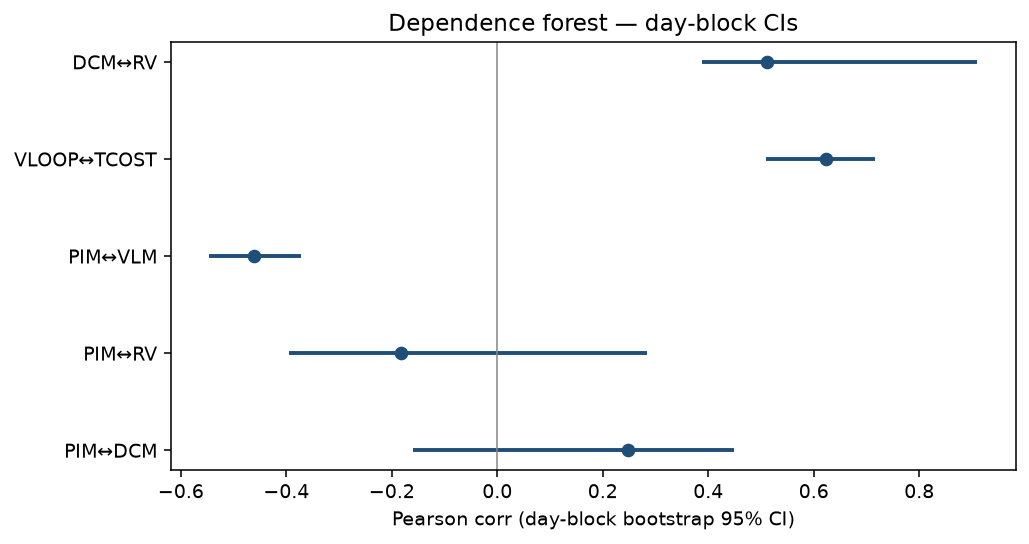

**fig_irf_pim_midret.png** — `out/feature_stats/figs/fig_irf_pim_midret.png`

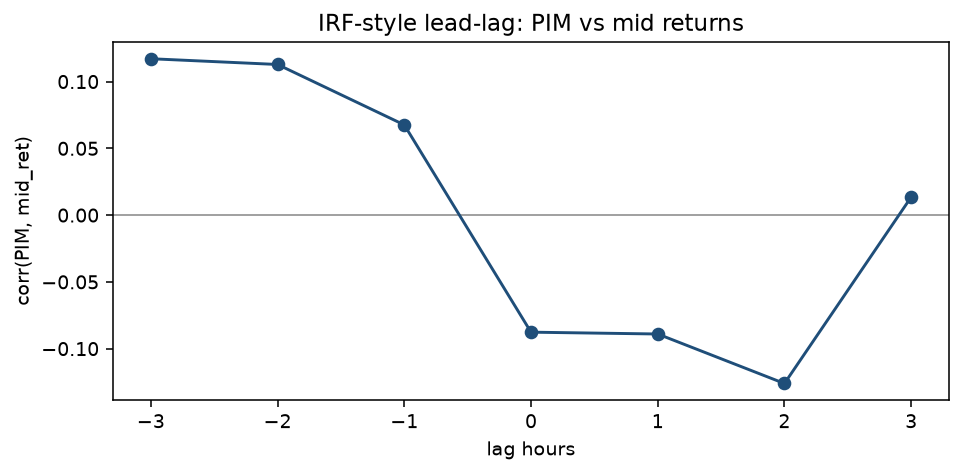

**fig_tod_heatmap.png** — `out/feature_stats/figs/fig_tod_heatmap.png`

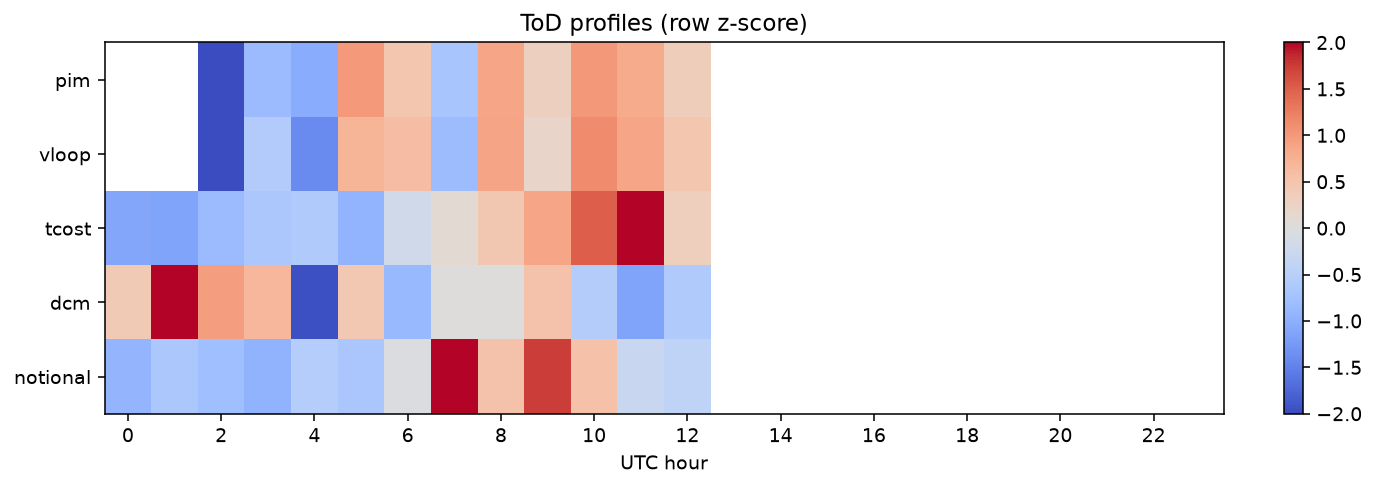

**fig_univariate_hists.png** — `out/feature_stats/figs/fig_univariate_hists.png`

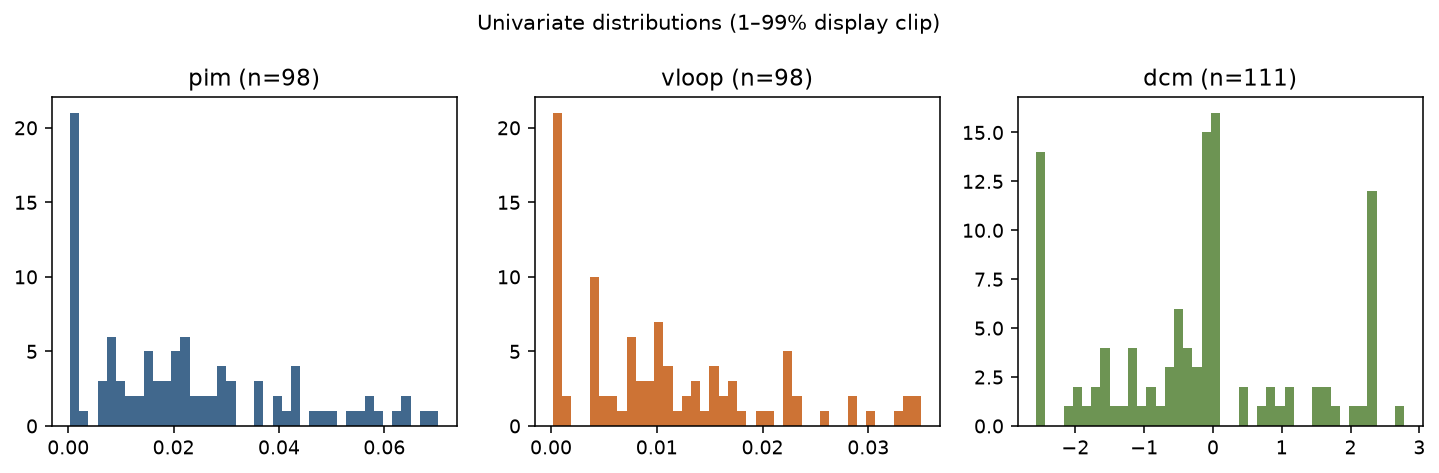

In [5]:
show_pngs(OUT / "feature_stats" / "figs")


## Object relations (quick matrix)

Contemporaneous Pearson on the joined hourly panel.


In [6]:
keys = ["pim__dcm", "pim__rv", "pim__notional", "pim__mid_ret", "vloop__tcost",
        "vloop__dcm", "tcost__dcm", "dcm__rv", "dcm__notional"]
print(f"{'pair':22s} {'pearson':>8s} {'spearman':>9s} {'n':>5s}  day-block CI")
print("-" * 70)
for k in keys:
    d = (info.get("dependence") or {}).get(k) or {}
    b = d.get("day_block") or {}
    ci = ""
    if b.get("ci_lo") is not None:
        ci = f"[{b['ci_lo']:.3f},{b['ci_hi']:.3f}]"
    print(f"{k:22s} {d.get('pearson', float('nan')):8.3f} {d.get('spearman', float('nan')):9.3f} "
          f"{int(d.get('n') or 0):5d}  {ci}")


pair                    pearson  spearman     n  day-block CI
----------------------------------------------------------------------
pim__dcm                  0.248     0.161    59  [-0.157,0.454]
pim__rv                  -0.182    -0.175    66  [-0.408,0.316]
pim__notional            -0.461    -0.528    88  [-0.545,-0.354]
pim__mid_ret             -0.088     0.221    66  [-0.255,0.077]
vloop__tcost              0.624     0.690    98  [0.480,0.707]
vloop__dcm                0.214     0.136    59  [-0.147,0.433]
tcost__dcm                0.029    -0.012   111  [-0.358,0.308]
dcm__rv                   0.511     0.603   111  [0.357,0.917]
dcm__notional            -0.247    -0.273   111  [-0.435,-0.033]


## Desk use map (honesty)

| Object | Risk monitor | Exec throttle | Tradable | Policy-only |
|--------|:------------:|:-------------:|:--------:|:-----------:|
| PIM | ✓ | maybe | **no** | — |
| VLOOP | ✓ | maybe (SOR context) | **no** | — |
| TCOST | — | ✓ friction | **no** | — |
| DCM̂ | ✓ regime | maybe | **no** | — |
| VLM↔PIM | ✓ liq | maybe | **no** | — |
| Kraken mode | — | — | **no** | ✓ spot_l2 vs 2-venue |

**Never:** soft-Promote TOB-cross α · resurrect `trade_synth` into primary · ClickHouse MCP.

Certified days must match DESK_MEMO / CHAPTER_INDEX / `out/panel_completeness/`.


In [7]:
# regenerate reminder
print("To rebuild dig on certified panel:")
print("  python3 scripts/exp_info_features.py --symbol ETH")
print("  python3 scripts/exp_feature_stats.py --symbol ETH")
print("Promote count:", (cands.get("_rollup") or {}).get("promote_count", "?"))
print("primary days:", PRIMARY)
print("has_synth on PIM summary:", (load_json(OUT / "pim_vloop_tcost" / "summary.json") or {}).get("has_synth"))


To rebuild dig on certified panel:
  python3 scripts/exp_info_features.py --symbol ETH
  python3 scripts/exp_feature_stats.py --symbol ETH
Promote count: 0
primary days: ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
has_synth on PIM summary: False
